# M10.1 · Cluster Quality & Persona Profiles (CRISP-DM Phase 5)

**What this notebook answers**

1. Are the clusters from `04_modeling/01_device_behavior_clustering.ipynb` *technically* sound — silhouette, Davies-Bouldin, Calinski-Harabasz?
2. Are they *interpretable*? Each cluster gets an auto-generated persona based on the per-feature z-score deviation from the tenant mean.
3. Are the cluster sizes balanced enough to be useful, or does one cluster swallow everything?

**Re-fits the model in-notebook** (deterministic, `random_state=42`) so this evaluation is reproducible without the parquet artifact.


## 1. Bootstrap

In [1]:
from __future__ import annotations
import sys, pathlib
PROJECT_ROOT = pathlib.Path().resolve().parents[1] if pathlib.Path().resolve().name != 'accent-fleet-analytics' else pathlib.Path().resolve()
for c in (PROJECT_ROOT, PROJECT_ROOT.parent):
    src = c / 'src'
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src)); break

import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
from accent_fleet.db import get_engine
from sqlalchemy import text

FEATURES = [
    'overspeed_per_100km', 'avg_speed_over_limit', 'high_speed_trip_ratio',
    'speed_alert_per_100km',
    'harsh_brake_per_100km', 'harsh_accel_per_100km', 'harsh_corner_per_100km',
    'monthly_idle_ratio', 'high_rpm_minutes_per_day',
    'night_trip_ratio', 'rush_hour_trip_ratio',
    'stddev_trip_distance', 'short_trip_ratio',
]
ID_COLS = ['tenant_id', 'device_id', 'year_month']

with get_engine().connect() as conn:
    df = pd.read_sql(text('''
        SELECT * FROM marts.v_ml_features_full
        WHERE year_month >= '2025-01'
          AND total_distance_km >= 100
          AND total_ignition_on_minutes > 0
    '''), conn)
print('feature rows:', len(df), '|', 'tenants:', sorted(df.tenant_id.unique().tolist()))

feature rows: 1723 | tenants: [235, 238, 264, 1787]


## 2. Re-fit per-tenant clustering (matches `04_modeling/01`)

Same logic as the modeling notebook: scale → KMeans(k=3..6) → silhouette-driven k. We additionally compute Davies-Bouldin (lower=better) and Calinski-Harabasz (higher=better) so we have three internal-validity views, not one.

In [2]:
def fit_one_tenant(sub: pd.DataFrame, k_range=range(3, 7)):
    X = sub[FEATURES].fillna(0).to_numpy()
    if len(X) < 50:
        return None
    Xs = StandardScaler().fit_transform(X)
    best = None
    for k in k_range:
        if k >= len(X):
            continue
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
        sil = silhouette_score(Xs, km.labels_)
        if best is None or sil > best['sil']:
            best = {'k': k, 'sil': sil, 'km': km, 'Xs': Xs, 'labels': km.labels_}
    db = davies_bouldin_score(best['Xs'], best['labels'])
    ch = calinski_harabasz_score(best['Xs'], best['labels'])
    out = sub[ID_COLS].copy(); out['cluster'] = best['labels']
    return {
        'best_k': best['k'], 'silhouette': best['sil'],
        'davies_bouldin': db, 'calinski_harabasz': ch,
        'labels': out, 'Xs': best['Xs'],
    }

results = {}
for tenant_id, sub in df.groupby('tenant_id'):
    r = fit_one_tenant(sub)
    if r is None:
        print(f'tenant {tenant_id}: only {len(sub)} rows -- skipped'); continue
    results[tenant_id] = r

metrics_df = pd.DataFrame({
    t: {'n': len(r['labels']), 'k': r['best_k'],
        'silhouette': round(r['silhouette'], 3),
        'davies_bouldin': round(r['davies_bouldin'], 3),
        'calinski_harabasz': round(r['calinski_harabasz'], 1)}
    for t, r in results.items()
}).T
metrics_df.index.name = 'tenant_id'
metrics_df

,n,k,silhouette,davies_bouldin,calinski_harabasz
tenant_id,,,,,
235,613.0,3.0,0.355,1.730,102.9
238,339.0,6.0,0.237,1.165,72.2
264,354.0,6.0,0.174,1.587,52.5
1787,417.0,6.0,0.278,1.220,81.9


## 3. Cluster size balance

A cluster that holds <5% of the tenant cohort is usually noise; a cluster holding >70% means the model is finding one large 'normal' blob and a few outliers. We flag both extremes.

In [3]:
balance_rows = []
for tenant_id, r in results.items():
    sizes = r['labels'].cluster.value_counts(normalize=True).sort_index()
    for cl, frac in sizes.items():
        balance_rows.append({'tenant_id': tenant_id, 'cluster': int(cl),
                             'share': round(float(frac), 3),
                             'flag': ('tiny <5%' if frac < 0.05 else
                                      'dominant >70%' if frac > 0.70 else 'ok')})
balance = pd.DataFrame(balance_rows)
balance

,tenant_id,cluster,share,flag
0,235,0,0.824,dominant >70%
1,235,1,0.049,tiny <5%
2,235,2,0.127,ok
3,238,0,0.363,ok
4,238,1,0.080,ok
5,238,2,0.021,tiny <5%
6,238,3,0.106,ok
7,238,4,0.021,tiny <5%
8,238,5,0.410,ok
9,264,0,0.020,tiny <5%


## 4. Auto-named personas

For each cluster we compute the per-feature **z-score relative to the tenant mean** and pick the top-2 features by absolute z-score to label the cluster. This is a heuristic, not a substitute for human review, but it makes the table directly readable for non-technical reviewers.

In [4]:
FEATURE_LABELS = {
    'overspeed_per_100km': 'overspeeds',
    'avg_speed_over_limit': 'speed-over-limit',
    'high_speed_trip_ratio': 'highway-trips',
    'speed_alert_per_100km': 'speed-alerts',
    'harsh_brake_per_100km': 'harsh-brakes',
    'harsh_accel_per_100km': 'harsh-accels',
    'harsh_corner_per_100km': 'harsh-corners',
    'monthly_idle_ratio': 'idle-time',
    'high_rpm_minutes_per_day': 'high-RPM',
    'night_trip_ratio': 'night-driving',
    'rush_hour_trip_ratio': 'rush-hour',
    'stddev_trip_distance': 'trip-variance',
    'short_trip_ratio': 'short-trips',
}

def name_cluster(z: pd.Series) -> str:
    top = z.abs().sort_values(ascending=False).head(2)
    parts = []
    for feat in top.index:
        arrow = 'high' if z[feat] > 0 else 'low'
        parts.append(f'{arrow} {FEATURE_LABELS.get(feat, feat)}')
    return ' + '.join(parts)

persona_rows = []
for tenant_id, r in results.items():
    full = r['labels'].merge(df[ID_COLS + FEATURES + ['total_distance_km']],
                             on=ID_COLS, how='left')
    tenant_mean = full[FEATURES].mean()
    tenant_std = full[FEATURES].std().replace(0, 1)
    for cl, sub in full.groupby('cluster'):
        z = (sub[FEATURES].mean() - tenant_mean) / tenant_std
        persona_rows.append({
            'tenant_id': tenant_id, 'cluster': int(cl), 'n': len(sub),
            'share': round(len(sub) / len(full), 3),
            'avg_distance_km': round(sub.total_distance_km.mean(), 1),
            'persona': name_cluster(z),
        })
personas = pd.DataFrame(persona_rows).sort_values(['tenant_id', 'cluster'])
personas

,tenant_id,cluster,n,share,avg_distance_km,persona
0,235,0,505,0.824,2985.7,low speed-over-limit + low overspeeds
1,235,1,30,0.049,1964.3,high harsh-corners + high harsh-accels
2,235,2,78,0.127,5376.8,high speed-over-limit + high overspeeds
3,238,0,123,0.363,2289.1,low night-driving + high rush-hour
4,238,1,27,0.080,3963.0,high high-RPM + high trip-variance
5,238,2,7,0.021,2222.8,high harsh-corners + high harsh-accels
6,238,3,36,0.106,3538.6,high highway-trips + high speed-over-limit
7,238,4,7,0.021,755.3,high speed-alerts + high idle-time
8,238,5,139,0.410,4342.6,high night-driving + high trip-variance
9,264,0,7,0.020,8699.3,high harsh-corners + low overspeeds


## 5. Per-tenant feature z-heatmap

Each row is a cluster, each column is a feature. Values are z-scores vs the tenant mean. Bright red = much higher than tenant average; deep blue = much lower. Use this to sanity-check the auto-generated personas.

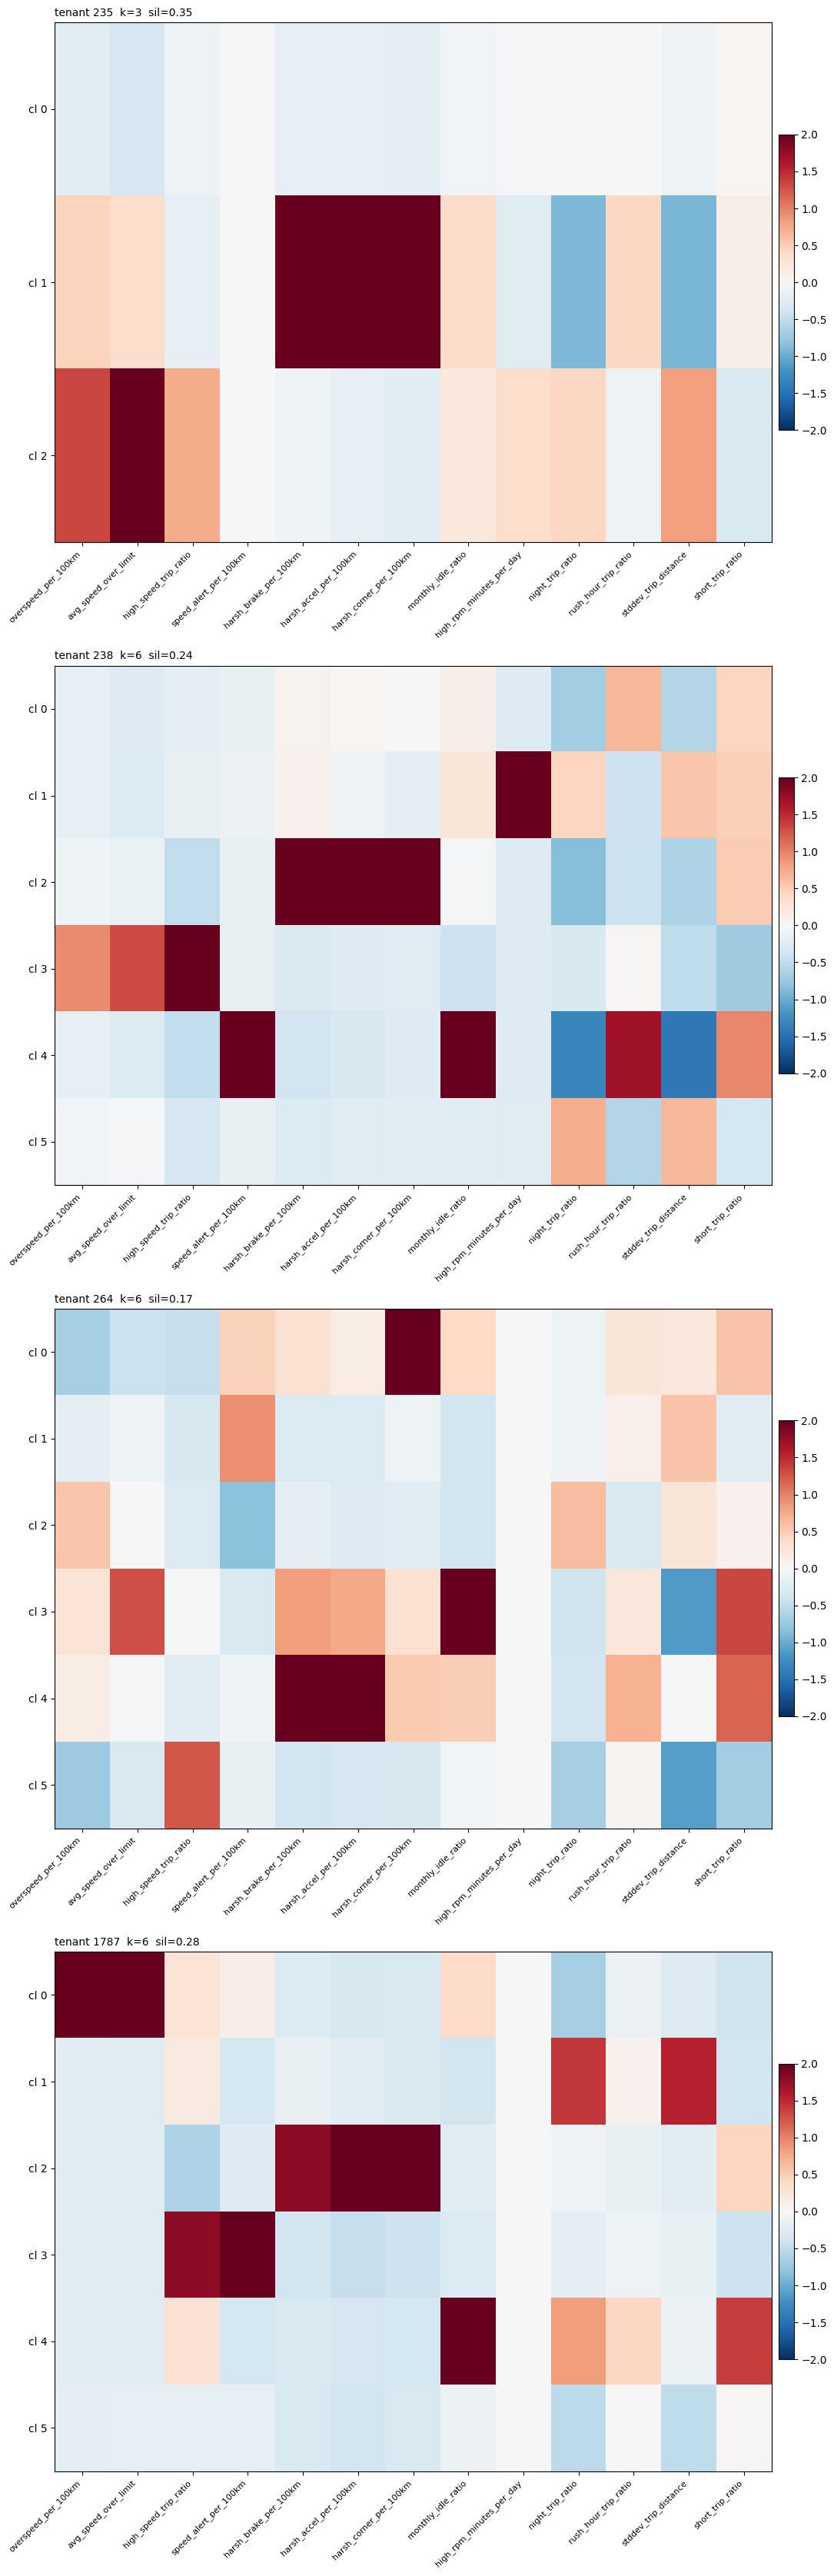

In [5]:
n = len(results)
fig, axes = plt.subplots(n, 1, figsize=(11, 1.6 * sum(r['best_k'] for r in results.values())), squeeze=False)
for ax, (tenant_id, r) in zip(axes[:, 0], results.items()):
    full = r['labels'].merge(df[ID_COLS + FEATURES], on=ID_COLS, how='left')
    mean = full[FEATURES].mean(); std = full[FEATURES].std().replace(0, 1)
    z = full.groupby('cluster')[FEATURES].mean().sub(mean).div(std)
    im = ax.imshow(z.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(z))); ax.set_yticklabels([f'cl {c}' for c in z.index])
    ax.set_title(f'tenant {tenant_id}  k={r["best_k"]}  sil={r["silhouette"]:.2f}', fontsize=10, loc='left')
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
plt.tight_layout(); plt.show()

## 6. Verdict

The exit gate from `04_modeling/01` was *every tenant must reach `best_k >= 3` and `silhouette >= 0.15`*. The technical numbers tell us whether the clusters are real; the persona table tells us whether they are useful. Both must hold.

In [6]:
passed_tech = all(r['silhouette'] >= 0.15 and r['best_k'] >= 3 for r in results.values())
big_dom = balance.query('flag == "dominant >70%"')
passed_balance = big_dom.empty
unique_personas_per_tenant = personas.groupby('tenant_id').persona.nunique()
passed_personas = (unique_personas_per_tenant >= 3).all()

verdict = {
    'silhouette_gate (>=0.15 & k>=3)': passed_tech,
    'no_dominant_cluster (>70%)': passed_balance,
    'distinct_personas (>=3 per tenant)': bool(passed_personas),
}
verdict_df = pd.DataFrame.from_dict(verdict, orient='index', columns=['pass'])
verdict_df

,pass
silhouette_gate (>=0.15 & k>=3),True
no_dominant_cluster (>70%),False
distinct_personas (>=3 per tenant),True


**Go / No-go.** If every row of the verdict table is `True`, clustering is releasable for the executive dashboard. If the silhouette gate fails for a tenant we ship the model only for the tenants that pass and document the gap. If the persona gate fails, we are producing labels we cannot explain — do not ship.

**Next action.** Pass labels to `02_risk_score_validation.ipynb` to check whether the *high-risk* clusters and the Isolation-Forest *high* band agree on which device-months are problematic.